In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import (
    resnet50,
    ResNet50_Weights
)

from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import cv2

In [23]:
TRAIN_DIR = "../data/COVID_19_dataset/train"
VAL_DIR = "../data/COVID_19_dataset/val"
TEST_DIR = "../data/COVID_19_dataset/test"

In [12]:
import json

with open("preprocessing_config.json", "r") as f:
    config = json.load(f)

In [13]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [14]:
from torchvision.models import (
    resnet50,
    ResNet50_Weights
)

model = resnet50(
    weights=ResNet50_Weights.IMAGENET1K_V2
)

In [15]:
num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    3
)

model = model.to(device)

In [16]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [17]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0

    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(
            outputs,
            1
        )

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [19]:
def evaluate(
    model,
    loader,
    criterion
):

    model.eval()

    loss_total = 0

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss_total += loss.item()

            _, preds = torch.max(
                outputs,
                1
            )

            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

    return (
        loss_total / len(loader),
        correct / total
    )

In [20]:
def apply_clahe(img):

    img = np.array(img)

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2GRAY
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    enhanced = clahe.apply(gray)

    enhanced = cv2.cvtColor(
        enhanced,
        cv2.COLOR_GRAY2RGB
    )

    return enhanced

In [21]:
train_transform = transforms.Compose([

    transforms.Lambda(apply_clahe),

    transforms.ToPILImage(),

    transforms.Resize((224,224)),

    transforms.RandomAffine(
        degrees=5,
        translate=(0.03,0.03)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5159]*3,
        std=[0.2280]*3
    )
])

val_test_transform = transforms.Compose([

    transforms.Lambda(apply_clahe),

    transforms.ToPILImage(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5159,0.5159,0.5159],
        std=[0.2280,0.2280,0.2280]
    )
])

In [25]:
train_dataset = ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset = ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

In [26]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [27]:
EPOCHS = 10
train_losses = []
val_losses = []

train_accs = []
val_accs = []
best_val_acc = 0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f}"
    )

    print(
        f"Train Acc: {train_acc:.4f}"
    )

    print(
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_resnet50.pth"
        )

C:\Users\Shantanu Ojha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/10
Train Loss: 0.6463
Val Loss: 0.4474
Train Acc: 0.7873
Val Acc: 0.8183
Epoch 2/10
Train Loss: 0.4208
Val Loss: 0.3354
Train Acc: 0.8537
Val Acc: 0.8867
Epoch 3/10
Train Loss: 0.3455
Val Loss: 0.3004
Train Acc: 0.8803
Val Acc: 0.8917
Epoch 4/10
Train Loss: 0.3292
Val Loss: 0.2878
Train Acc: 0.8790
Val Acc: 0.8800
Epoch 5/10
Train Loss: 0.3008
Val Loss: 0.2601
Train Acc: 0.8903
Val Acc: 0.9083
Epoch 6/10
Train Loss: 0.2784
Val Loss: 0.2534
Train Acc: 0.8960
Val Acc: 0.9033
Epoch 7/10
Train Loss: 0.2717
Val Loss: 0.2293
Train Acc: 0.9023
Val Acc: 0.9233
Epoch 8/10
Train Loss: 0.2505
Val Loss: 0.2455
Train Acc: 0.9143
Val Acc: 0.9083
Epoch 9/10
Train Loss: 0.2519
Val Loss: 0.2161
Train Acc: 0.9123
Val Acc: 0.9267
Epoch 10/10
Train Loss: 0.2372
Val Loss: 0.2181
Train Acc: 0.9180
Val Acc: 0.9200


In [31]:
model.load_state_dict(
    torch.load(
        "best_resnet50.pth",
        map_location=device
    )
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [32]:
y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

In [33]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9264
Precision: 0.9264
Recall   : 0.9264
F1 Score : 0.9261


In [34]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=test_dataset.classes
    )
)


                 precision    recall  f1-score   support

          COVID       0.94      0.91      0.92       145
         Normal       0.91      0.89      0.90       145
Viral Pneumonia       0.93      0.98      0.95       145

       accuracy                           0.93       435
      macro avg       0.93      0.93      0.93       435
   weighted avg       0.93      0.93      0.93       435



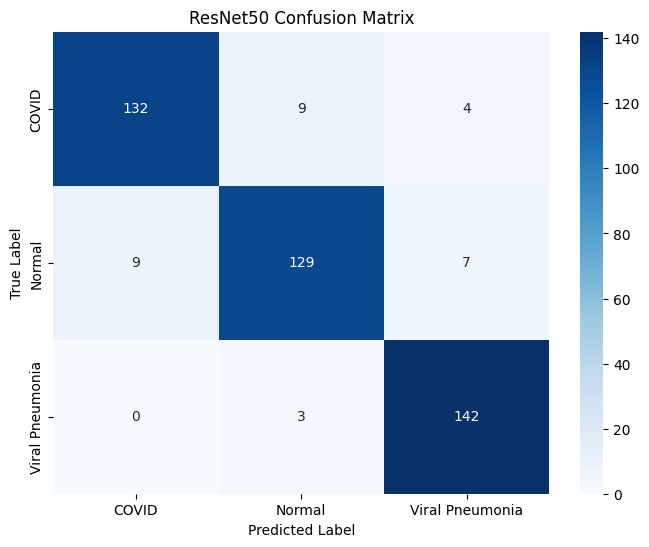

In [41]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet50 Confusion Matrix")

plt.savefig(
    "resnet50_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
baseline_results = {
    "accuracy": 0.9264,
    "precision": 0.9264,
    "recall": 0.9264,
    "f1": 0.9261
}

import json

with open(
    "resnet50_results.json",
    "w"
) as f:
    json.dump(
        baseline_results,
        f,
        indent=4
    )
